In [1]:
print("Hello! My College Placement Intelligence project has started.")

Hello! My College Placement Intelligence project has started.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# Load the placement dataset

df = pd.read_csv("data/Placement_Data_Full_Class.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 215
Columns: 15


In [4]:
# Display all column names

print("Column names:")
print(df.columns.tolist())

Column names:
['sl_no', 'gender', 'ssc_p', 'ssc_b', 'hsc_p', 'hsc_b', 'hsc_s', 'degree_p', 'degree_t', 'workex', 'etest_p', 'specialisation', 'mba_p', 'status', 'salary']


In [5]:
# Display the first 5 rows of the dataset

df.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


In [6]:
# Check the data types of each column

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           215 non-null    int64  
 1   gender          215 non-null    str    
 2   ssc_p           215 non-null    float64
 3   ssc_b           215 non-null    str    
 4   hsc_p           215 non-null    float64
 5   hsc_b           215 non-null    str    
 6   hsc_s           215 non-null    str    
 7   degree_p        215 non-null    float64
 8   degree_t        215 non-null    str    
 9   workex          215 non-null    str    
 10  etest_p         215 non-null    float64
 11  specialisation  215 non-null    str    
 12  mba_p           215 non-null    float64
 13  status          215 non-null    str    
 14  salary          148 non-null    float64
dtypes: float64(6), int64(1), str(8)
memory usage: 35.0 KB


In [7]:
# Check for missing values

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64


In [8]:
# Check for duplicate rows

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [9]:
# Remove the serial number column

df = df.drop(columns=["sl_no"])

print("sl_no column removed.")
print("New number of columns:", df.shape[1])

sl_no column removed.
New number of columns: 14


In [10]:
# Display summary statistics for numerical columns

df.describe()

,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
count,215.000000,215.000000,215.000000,215.000000,215.000000,148.000000
mean,67.303395,66.333163,66.370186,72.100558,62.278186,288655.405405
std,10.827205,10.897509,7.358743,13.275956,5.833385,93457.452420
min,40.890000,37.000000,50.000000,50.000000,51.210000,200000.000000
25%,60.600000,60.900000,61.000000,60.000000,57.945000,240000.000000
50%,67.000000,65.000000,66.000000,71.000000,62.000000,265000.000000
75%,75.700000,73.000000,72.000000,83.500000,66.255000,300000.000000
max,89.400000,97.700000,91.000000,98.000000,77.890000,940000.000000


In [11]:
# Calculate placement rate

placement_count = (df["status"] == "Placed").sum()
total_students = len(df)

placement_rate = (placement_count / total_students) * 100

print("Total Students:", total_students)
print("Placed Students:", placement_count)
print(f"Placement Rate: {placement_rate:.2f}%")

Total Students: 215
Placed Students: 148
Placement Rate: 68.84%


In [14]:
# Calculate average salary of placed students

placed_students = df[df["status"] == "Placed"]

average_salary = placed_students["salary"].mean()

print(f"Average Salary: {average_salary:.2f} LPA")

Average Salary: 288655.41 LPA


In [15]:
# Calculate the highest salary among placed students

highest_salary = placed_students["salary"].max()

print(f"Highest Salary: {highest_salary:.2f} LPA")

Highest Salary: 940000.00 LPA


In [16]:
# Calculate average academic scores

average_ssc = df["ssc_p"].mean()
average_hsc = df["hsc_p"].mean()
average_degree = df["degree_p"].mean()

print(f"Average SSC Percentage: {average_ssc:.2f}%")
print(f"Average HSC Percentage: {average_hsc:.2f}%")
print(f"Average Degree Percentage: {average_degree:.2f}%")

Average SSC Percentage: 67.30%
Average HSC Percentage: 66.33%
Average Degree Percentage: 66.37%


In [17]:
# Count placed and not placed students

status_counts = df["status"].value_counts()

print(status_counts)

status
Placed        148
Not Placed     67
Name: count, dtype: int64


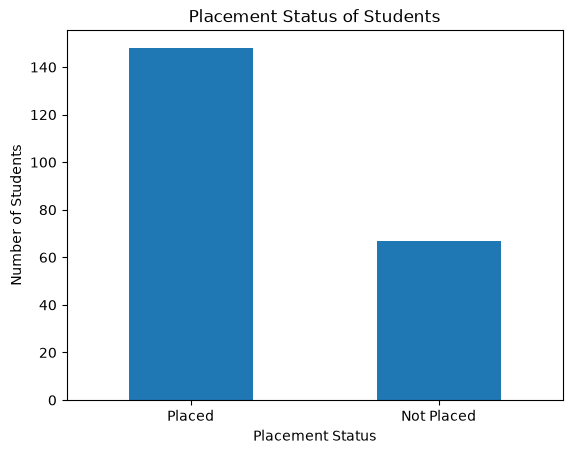

In [18]:
# Visualize placement status

status_counts.plot(kind="bar")

plt.title("Placement Status of Students")
plt.xlabel("Placement Status")
plt.ylabel("Number of Students")

plt.xticks(rotation=0)
plt.show()

In [21]:
# Placement rate by work experience

workex_placement = pd.crosstab(
    df["workex"],
    df["status"],
    normalize="index"
) * 100

print(workex_placement)

status  Not Placed     Placed
workex                       
No       40.425532  59.574468
Yes      13.513514  86.486486


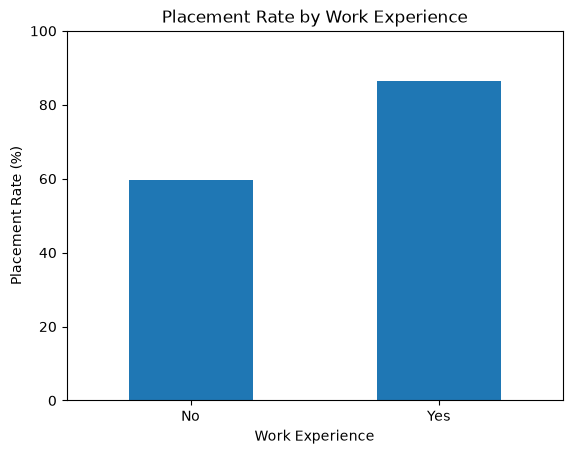

In [22]:
# Visualize placement rate by work experience

workex_placement["Placed"].plot(kind="bar")

plt.title("Placement Rate by Work Experience")
plt.xlabel("Work Experience")
plt.ylabel("Placement Rate (%)")
plt.xticks(rotation=0)
plt.ylim(0, 100)

plt.show()

In [23]:
# Create degree percentage groups

df["degree_group"] = pd.cut(
    df["degree_p"],
    bins=[0, 60, 70, 80, 100],
    labels=["Below 60", "60-70", "70-80", "80+"]
)

print(df["degree_group"].value_counts().sort_index())

degree_group
Below 60     48
60-70       105
70-80        55
80+           7
Name: count, dtype: int64


In [24]:
# Calculate placement rate for each degree percentage group

degree_placement = pd.crosstab(
    df["degree_group"],
    df["status"],
    normalize="index"
) * 100

print(degree_placement)

status        Not Placed      Placed
degree_group                        
Below 60       68.750000   31.250000
60-70          26.666667   73.333333
70-80          10.909091   89.090909
80+             0.000000  100.000000


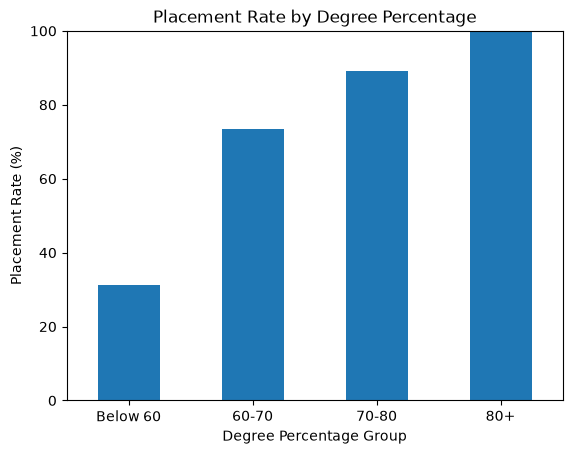

In [25]:
# Visualize placement rate by degree percentage

degree_placement["Placed"].plot(kind="bar")

plt.title("Placement Rate by Degree Percentage")
plt.xlabel("Degree Percentage Group")
plt.ylabel("Placement Rate (%)")
plt.xticks(rotation=0)
plt.ylim(0, 100)

plt.show()

In [26]:
# Create entrance-test score groups

df["etest_group"] = pd.cut(
    df["etest_p"],
    bins=[0, 50, 60, 70, 80, 100],
    labels=["Below 50", "50-60", "60-70", "70-80", "80+"]
)

print(df["etest_group"].value_counts().sort_index())

etest_group
Below 50     3
50-60       56
60-70       48
70-80       47
80+         61
Name: count, dtype: int64


In [27]:
# Calculate placement rate by entrance-test score group

etest_placement = pd.crosstab(
    df["etest_group"],
    df["status"],
    normalize="index"
) * 100

print(etest_placement)

status       Not Placed     Placed
etest_group                       
Below 50      66.666667  33.333333
50-60         33.928571  66.071429
60-70         35.416667  64.583333
70-80         36.170213  63.829787
80+           19.672131  80.327869


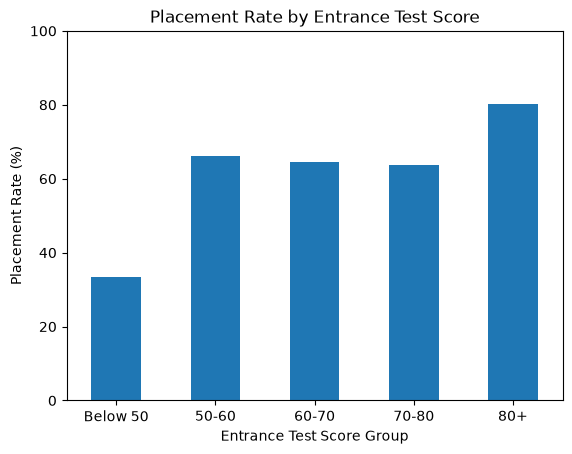

In [28]:
# Visualize placement rate by entrance-test score

etest_placement["Placed"].plot(kind="bar")

plt.title("Placement Rate by Entrance Test Score")
plt.xlabel("Entrance Test Score Group")
plt.ylabel("Placement Rate (%)")
plt.xticks(rotation=0)
plt.ylim(0, 100)

plt.show()

In [29]:
# Create MBA percentage groups

df["mba_group"] = pd.cut(
    df["mba_p"],
    bins=[0, 55, 65, 75, 85, 100],
    labels=["Below 55", "55-65", "65-75", "75-85", "85+"]
)

print(df["mba_group"].value_counts().sort_index())

mba_group
Below 55     22
55-65       124
65-75        65
75-85         4
85+           0
Name: count, dtype: int64


In [30]:
# Calculate placement rate by MBA percentage group

mba_placement = pd.crosstab(
    df["mba_group"],
    df["status"],
    normalize="index"
) * 100

print(mba_placement)

status     Not Placed     Placed
mba_group                       
Below 55    36.363636  63.636364
55-65       32.258065  67.741935
65-75       27.692308  72.307692
75-85       25.000000  75.000000


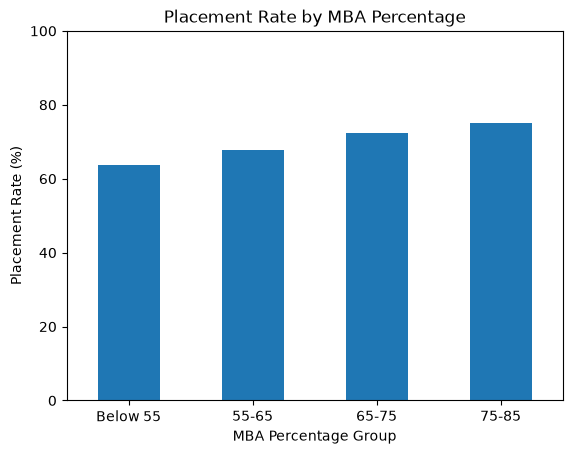

In [31]:
# Visualize placement rate by MBA percentage

mba_placement["Placed"].plot(kind="bar")

plt.title("Placement Rate by MBA Percentage")
plt.xlabel("MBA Percentage Group")
plt.ylabel("Placement Rate (%)")
plt.xticks(rotation=0)
plt.ylim(0, 100)

plt.show()

In [32]:
# Calculate placement rate by MBA specialization

specialisation_placement = pd.crosstab(
    df["specialisation"],
    df["status"],
    normalize="index"
) * 100

print(specialisation_placement)

status          Not Placed     Placed
specialisation                       
Mkt&Fin          20.833333  79.166667
Mkt&HR           44.210526  55.789474


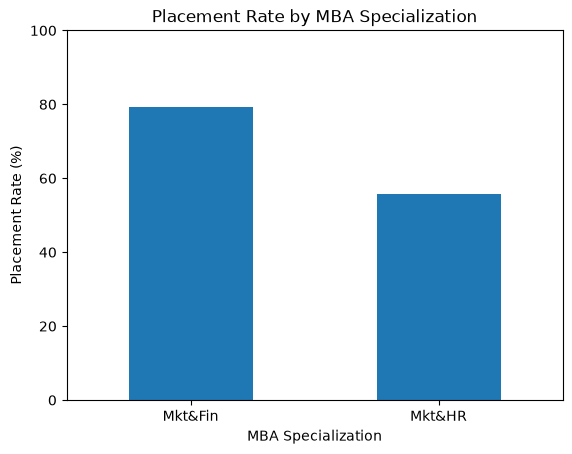

In [33]:
# Visualize placement rate by specialization

specialisation_placement["Placed"].plot(kind="bar")

plt.title("Placement Rate by MBA Specialization")
plt.xlabel("MBA Specialization")
plt.ylabel("Placement Rate (%)")
plt.xticks(rotation=0)
plt.ylim(0, 100)

plt.show()

In [34]:
# Calculate average salary by MBA specialization

salary_by_specialisation = (
    placed_students
    .groupby("specialisation")["salary"]
    .mean()
    .sort_values(ascending=False)
)

print(salary_by_specialisation)

specialisation
Mkt&Fin    298852.631579
Mkt&HR     270377.358491
Name: salary, dtype: float64


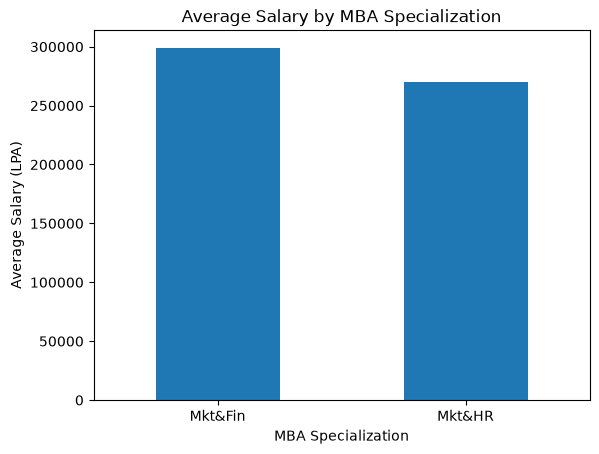

In [35]:
# Visualize average salary by MBA specialization

salary_by_specialisation.plot(kind="bar")

plt.title("Average Salary by MBA Specialization")
plt.xlabel("MBA Specialization")
plt.ylabel("Average Salary (LPA)")
plt.xticks(rotation=0)

plt.show()

In [36]:
# Select numerical columns for correlation analysis

numeric_columns = [
    "ssc_p",
    "hsc_p",
    "degree_p",
    "etest_p",
    "mba_p",
    "salary"
]

correlation_matrix = df[numeric_columns].corr()

correlation_matrix

,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
ssc_p,1.000000,0.511472,0.538404,0.261993,0.388478,0.035330
hsc_p,0.511472,1.000000,0.434206,0.245113,0.354823,0.076819
degree_p,0.538404,0.434206,1.000000,0.224470,0.402364,-0.019272
etest_p,0.261993,0.245113,0.224470,1.000000,0.218055,0.178307
mba_p,0.388478,0.354823,0.402364,0.218055,1.000000,0.175013
salary,0.035330,0.076819,-0.019272,0.178307,0.175013,1.000000


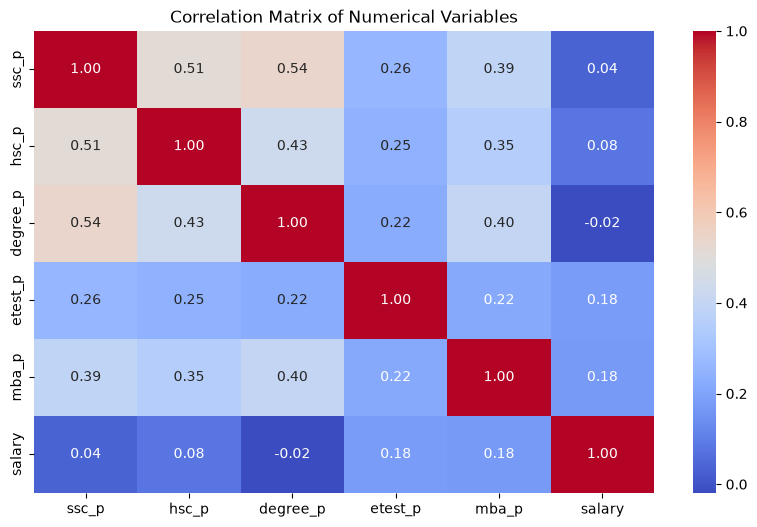

In [37]:
# Visualize correlations using a heatmap

plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Variables")
plt.show()

In [6]:
import pandas as pd

df = pd.read_csv("data/Placement_Data_Full_Class.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 215
Columns: 15


In [7]:
df = df.drop(columns=["sl_no"])

print("sl_no column removed.")
print("New number of columns:", df.shape[1])

sl_no column removed.
New number of columns: 14


In [8]:
# Create a copy for machine learning

ml_df = df.copy()

# Convert the placement status into 0 and 1
# 1 = Placed
# 0 = Not Placed

ml_df["placement_target"] = (
    ml_df["status"] == "Placed"
).astype(int)

print("Machine learning dataset created.")
print(ml_df["placement_target"].value_counts())

Machine learning dataset created.
placement_target
1    148
0     67
Name: count, dtype: int64


In [9]:
# Check the target distribution

print("Not Placed:", (ml_df["placement_target"] == 0).sum())
print("Placed:", (ml_df["placement_target"] == 1).sum())

Not Placed: 67
Placed: 148


In [10]:
# Select features that are known before placement happens
# We do NOT use status or salary because they would cause target leakage.

features = [
    "gender",
    "ssc_p",
    "ssc_b",
    "hsc_p",
    "hsc_b",
    "hsc_s",
    "degree_p",
    "degree_t",
    "workex",
    "etest_p",
    "specialisation",
    "mba_p"
]

X = ml_df[features]
y = ml_df["placement_target"]

print("Features selected for prediction:")
print(features)

print("\nFeature dataset shape:", X.shape)
print("Target dataset shape:", y.shape)

Features selected for prediction:
['gender', 'ssc_p', 'ssc_b', 'hsc_p', 'hsc_b', 'hsc_s', 'degree_p', 'degree_t', 'workex', 'etest_p', 'specialisation', 'mba_p']

Feature dataset shape: (215, 12)
Target dataset shape: (215,)


In [12]:
from sklearn.model_selection import train_test_split

print("train_test_split imported successfully!")

train_test_split imported successfully!


In [13]:
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 172
Testing samples: 43


In [15]:
# Separate numerical and categorical features

numeric_features = [
    "ssc_p",
    "hsc_p",
    "degree_p",
    "etest_p",
    "mba_p"
]

categorical_features = [
    "gender",
    "ssc_b",
    "hsc_b",
    "hsc_s",
    "degree_t",
    "workex",
    "specialisation"
]

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p']

Categorical features:
['gender', 'ssc_b', 'hsc_b', 'hsc_s', 'degree_t', 'workex', 'specialisation']


In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Preprocessing for numerical and categorical features

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Create the complete machine learning pipeline

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

print("Preprocessing pipeline and Logistic Regression model created successfully!")

Preprocessing pipeline and Logistic Regression model created successfully!


In [18]:
# Train the Logistic Regression model

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [19]:
# Make predictions on the test dataset

y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred))

Predictions generated successfully!
Number of predictions: 43


In [21]:
from sklearn.metrics import accuracy_score

print("accuracy_score imported successfully!")

accuracy_score imported successfully!


In [22]:
# Evaluate model accuracy

accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 86.05%


In [24]:
from sklearn.metrics import precision_score, recall_score

print("Precision and recall imported successfully!")

Precision and recall imported successfully!


In [25]:
# Calculate precision and recall

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Precision: {precision:.2%}")
print(f"Recall: {recall:.2%}")

Precision: 92.86%
Recall: 86.67%


In [27]:
from sklearn.metrics import confusion_matrix

print("confusion_matrix imported successfully!")

confusion_matrix imported successfully!


In [28]:
# Create the confusion matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[11  2]
 [ 4 26]]


In [30]:
from sklearn.metrics import classification_report

print("classification_report imported successfully!")

classification_report imported successfully!


In [31]:
# Generate a detailed classification report

print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Not Placed", "Placed"]
    )
)

Classification Report:
              precision    recall  f1-score   support

  Not Placed       0.73      0.85      0.79        13
      Placed       0.93      0.87      0.90        30

    accuracy                           0.86        43
   macro avg       0.83      0.86      0.84        43
weighted avg       0.87      0.86      0.86        43



In [32]:
# Imports needed for model evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

print("All model evaluation tools imported successfully!")

All model evaluation tools imported successfully!


In [33]:
print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Not Placed", "Placed"]
    )
)

Classification Report:
              precision    recall  f1-score   support

  Not Placed       0.73      0.85      0.79        13
      Placed       0.93      0.87      0.90        30

    accuracy                           0.86        43
   macro avg       0.83      0.86      0.84        43
weighted avg       0.87      0.86      0.86        43



In [34]:
# Generate placement probabilities for the test students

placement_probability = model.predict_proba(X_test)[:, 1]

print("Placement probabilities generated successfully!")
print("First 10 probabilities:")
print(placement_probability[:10])

Placement probabilities generated successfully!
First 10 probabilities:
[0.78535861 0.99849416 0.9918353  0.35528412 0.92255411 0.57887065
 0.9278058  0.92829296 0.06520882 0.99717049]


In [35]:
# Convert placement probability into project-defined risk categories

def classify_risk(probability):
    if probability >= 0.70:
        return "Lower Risk"
    elif probability >= 0.40:
        return "Medium Risk"
    else:
        return "Higher Risk"


risk_categories = [
    classify_risk(probability)
    for probability in placement_probability
]

risk_counts = pd.Series(risk_categories).value_counts()

print("Risk category distribution:")
print(risk_counts)

Risk category distribution:
Lower Risk     25
Higher Risk    13
Medium Risk     5
Name: count, dtype: int64


In [36]:
# Create a prediction results table for the test students

prediction_results = X_test.copy()

prediction_results["Actual Placement"] = y_test.values
prediction_results["Predicted Placement"] = y_pred
prediction_results["Placement Probability"] = placement_probability
prediction_results["Risk Category"] = risk_categories

# Convert 0/1 into readable labels
prediction_results["Actual Placement"] = prediction_results["Actual Placement"].map({
    0: "Not Placed",
    1: "Placed"
})

prediction_results["Predicted Placement"] = prediction_results["Predicted Placement"].map({
    0: "Not Placed",
    1: "Placed"
})

prediction_results.head(10)

,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,Actual Placement,Predicted Placement,Placement Probability,Risk Category
63,M,61.0,Others,70.00,Others,Commerce,64.00,Comm&Mgmt,No,68.50,Mkt&HR,59.50,Not Placed,Placed,0.785359,Lower Risk
60,M,74.0,Central,70.00,Central,Science,72.00,Comm&Mgmt,Yes,60.00,Mkt&Fin,57.24,Placed,Placed,0.998494,Lower Risk
132,M,67.0,Others,68.00,Others,Commerce,64.00,Comm&Mgmt,Yes,74.40,Mkt&HR,53.49,Placed,Placed,0.991835,Lower Risk
75,F,59.0,Central,62.00,Others,Commerce,77.50,Comm&Mgmt,No,74.00,Mkt&HR,67.00,Not Placed,Not Placed,0.355284,Higher Risk
16,M,63.0,Central,66.20,Central,Commerce,65.60,Comm&Mgmt,Yes,60.00,Mkt&Fin,62.54,Placed,Placed,0.922554,Lower Risk
190,F,64.0,Others,70.20,Central,Commerce,61.00,Comm&Mgmt,No,50.00,Mkt&Fin,62.50,Not Placed,Placed,0.578871,Medium Risk
76,F,66.5,Others,70.40,Central,Arts,71.93,Comm&Mgmt,No,61.00,Mkt&Fin,64.27,Placed,Placed,0.927806,Lower Risk
35,F,69.0,Central,78.00,Central,Commerce,72.00,Comm&Mgmt,No,71.00,Mkt&HR,62.74,Placed,Placed,0.928293,Lower Risk
51,M,54.4,Central,61.12,Central,Commerce,56.20,Comm&Mgmt,No,67.00,Mkt&HR,62.65,Not Placed,Not Placed,0.065209,Higher Risk
66,M,83.0,Others,74.00,Others,Science,66.00,Comm&Mgmt,No,68.92,Mkt&HR,58.46,Placed,Placed,0.997170,Lower Risk


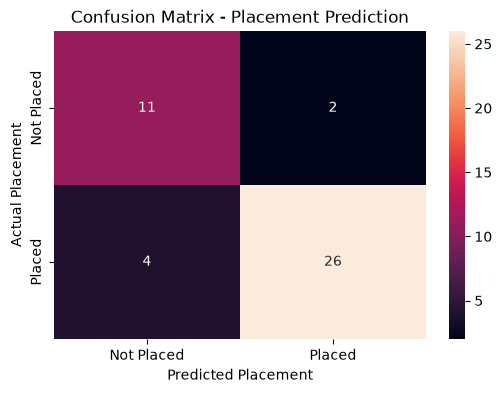

In [37]:
# Visualize the confusion matrix

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Not Placed", "Placed"],
    yticklabels=["Not Placed", "Placed"]
)

plt.title("Confusion Matrix - Placement Prediction")
plt.xlabel("Predicted Placement")
plt.ylabel("Actual Placement")

plt.show()

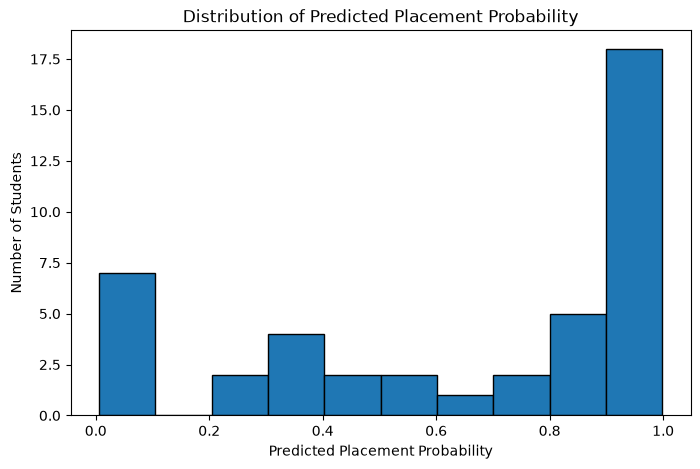

In [38]:
# Visualize placement probability distribution

plt.figure(figsize=(8, 5))

plt.hist(
    placement_probability,
    bins=10,
    edgecolor="black"
)

plt.title("Distribution of Predicted Placement Probability")
plt.xlabel("Predicted Placement Probability")
plt.ylabel("Number of Students")

plt.show()

In [2]:
# ============================================================
# PROJECT SETUP — RUN THIS CELL AFTER A KERNEL RESTART
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

# Load dataset
df = pd.read_csv("data/Placement_Data_Full_Class.csv")

# Remove serial number
df = df.drop(columns=["sl_no"])

# Create machine-learning target
ml_df = df.copy()

ml_df["placement_target"] = (
    ml_df["status"] == "Placed"
).astype(int)

# Select prediction features
features = [
    "gender",
    "ssc_p",
    "ssc_b",
    "hsc_p",
    "hsc_b",
    "hsc_s",
    "degree_p",
    "degree_t",
    "workex",
    "etest_p",
    "specialisation",
    "mba_p"
]

X = ml_df[features]
y = ml_df["placement_target"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Numerical and categorical features
numeric_features = [
    "ssc_p",
    "hsc_p",
    "degree_p",
    "etest_p",
    "mba_p"
]

categorical_features = [
    "gender",
    "ssc_b",
    "hsc_b",
    "hsc_s",
    "degree_t",
    "workex",
    "specialisation"
]

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Model
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

# Train
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Probabilities
placement_probability = model.predict_proba(X_test)[:, 1]

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Project setup completed successfully!")
print("Dataset:", df.shape)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Project setup completed successfully!
Dataset: (215, 14)
Training samples: 172
Testing samples: 43


Placement rate by work experience:
status  Not Placed     Placed
workex                       
No       40.425532  59.574468
Yes      13.513514  86.486486


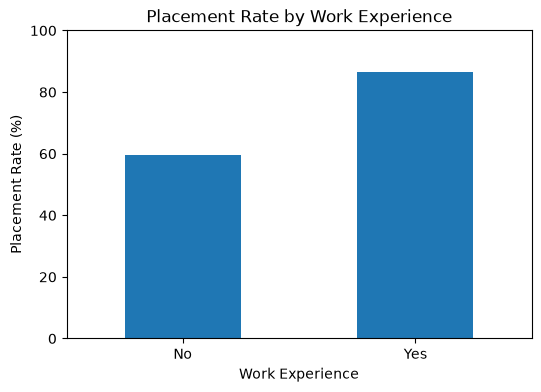

In [3]:
# Analyze placement rate by work experience

import pandas as pd
import matplotlib.pyplot as plt

workex_placement = pd.crosstab(
    df["workex"],
    df["status"],
    normalize="index"
) * 100

print("Placement rate by work experience:")
print(workex_placement)

plt.figure(figsize=(6, 4))

workex_placement["Placed"].plot(kind="bar")

plt.title("Placement Rate by Work Experience")
plt.xlabel("Work Experience")
plt.ylabel("Placement Rate (%)")
plt.xticks(rotation=0)
plt.ylim(0, 100)

plt.show()

In [4]:
workex_placement = pd.crosstab(
    df["workex"],
    df["status"],
    normalize="index"
) * 100

In [5]:
# ============================================================
# BUSINESS INTELLIGENCE KPI SUMMARY
# ============================================================

# Total students
total_students = len(df)

# Placement metrics
placed_students = df[df["status"] == "Placed"]
placed_count = len(placed_students)

placement_rate = (placed_count / total_students) * 100

# Salary metrics
average_salary = placed_students["salary"].mean()
highest_salary = placed_students["salary"].max()

# Academic metrics
average_ssc = df["ssc_p"].mean()
average_hsc = df["hsc_p"].mean()
average_degree = df["degree_p"].mean()
average_mba = df["mba_p"].mean()

# Create KPI table
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Students",
        "Placed Students",
        "Placement Rate (%)",
        "Average Salary (LPA)",
        "Highest Salary (LPA)",
        "Average SSC (%)",
        "Average HSC (%)",
        "Average Degree (%)",
        "Average MBA (%)"
    ],
    "Value": [
        total_students,
        placed_count,
        round(placement_rate, 2),
        round(average_salary, 2),
        round(highest_salary, 2),
        round(average_ssc, 2),
        round(average_hsc, 2),
        round(average_degree, 2),
        round(average_mba, 2)
    ]
})

print("College Placement Intelligence — KPI Summary")
display(kpi_summary)

College Placement Intelligence — KPI Summary


,KPI,Value
0,Total Students,215.00
1,Placed Students,148.00
2,Placement Rate (%),68.84
3,Average Salary (LPA),288655.41
4,Highest Salary (LPA),940000.00
5,Average SSC (%),67.30
6,Average HSC (%),66.33
7,Average Degree (%),66.37
8,Average MBA (%),62.28


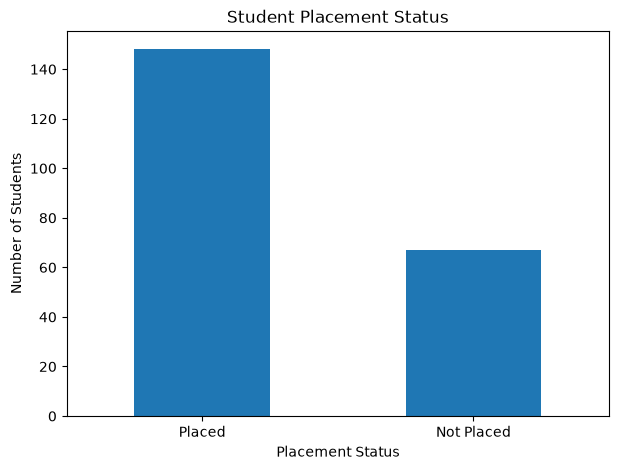

In [6]:
# ============================================================
# EXECUTIVE OVERVIEW — PLACEMENT STATUS
# ============================================================

status_counts = df["status"].value_counts()

plt.figure(figsize=(7, 5))

status_counts.plot(kind="bar")

plt.title("Student Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)

plt.show()

Placement rate by degree percentage:


status,Not Placed,Placed
degree_group,,
Below 60,68.750000,31.250000
60-70,26.666667,73.333333
70-80,10.909091,89.090909
80+,0.000000,100.000000


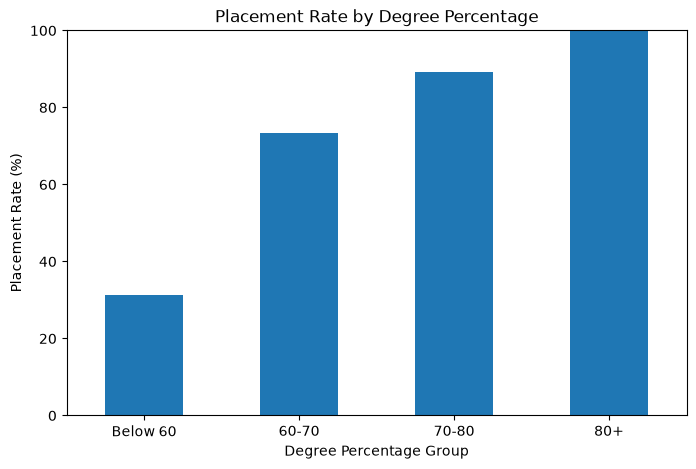

In [7]:
# ============================================================
# DIAGNOSTIC ANALYSIS — DEGREE PERFORMANCE
# ============================================================

# Create degree percentage groups
df["degree_group"] = pd.cut(
    df["degree_p"],
    bins=[0, 60, 70, 80, 100],
    labels=["Below 60", "60-70", "70-80", "80+"]
)

# Calculate placement rate for each group
degree_placement = pd.crosstab(
    df["degree_group"],
    df["status"],
    normalize="index"
) * 100

print("Placement rate by degree percentage:")
display(degree_placement)

# Visualize placement rate
plt.figure(figsize=(8, 5))

degree_placement["Placed"].plot(kind="bar")

plt.title("Placement Rate by Degree Percentage")
plt.xlabel("Degree Percentage Group")
plt.ylabel("Placement Rate (%)")
plt.xticks(rotation=0)
plt.ylim(0, 100)

plt.show()

Placement rate by entrance test score:


status,Not Placed,Placed
etest_group,,
Below 50,66.666667,33.333333
50-60,33.928571,66.071429
60-70,35.416667,64.583333
70-80,36.170213,63.829787
80+,19.672131,80.327869


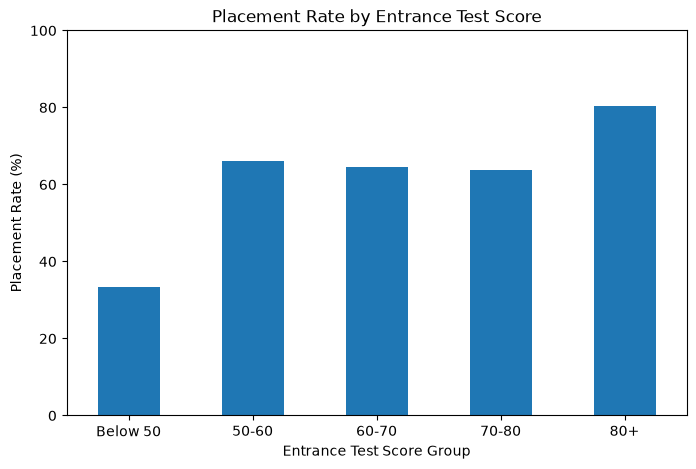

In [8]:
# ============================================================
# DIAGNOSTIC ANALYSIS — ENTRANCE TEST SCORE
# ============================================================

df["etest_group"] = pd.cut(
    df["etest_p"],
    bins=[0, 50, 60, 70, 80, 100],
    labels=["Below 50", "50-60", "60-70", "70-80", "80+"]
)

etest_placement = pd.crosstab(
    df["etest_group"],
    df["status"],
    normalize="index"
) * 100

print("Placement rate by entrance test score:")
display(etest_placement)

plt.figure(figsize=(8, 5))

etest_placement["Placed"].plot(kind="bar")

plt.title("Placement Rate by Entrance Test Score")
plt.xlabel("Entrance Test Score Group")
plt.ylabel("Placement Rate (%)")
plt.xticks(rotation=0)
plt.ylim(0, 100)

plt.show()

Placement rate by MBA specialization:


status,Not Placed,Placed
specialisation,,
Mkt&Fin,20.833333,79.166667
Mkt&HR,44.210526,55.789474


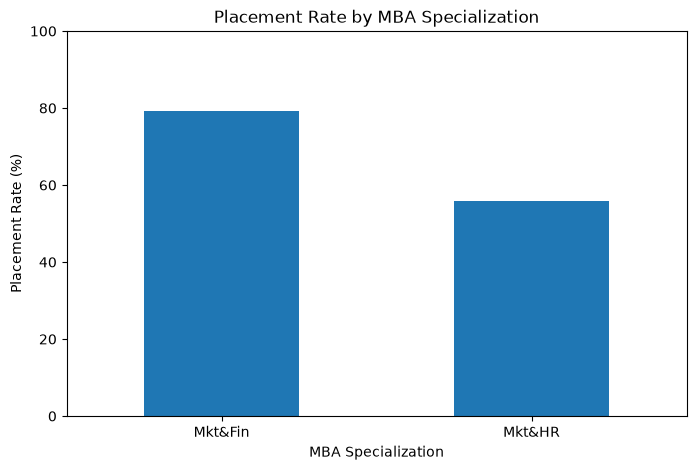

In [9]:
# ============================================================
# DIAGNOSTIC ANALYSIS — MBA SPECIALIZATION
# ============================================================

specialisation_placement = pd.crosstab(
    df["specialisation"],
    df["status"],
    normalize="index"
) * 100

print("Placement rate by MBA specialization:")
display(specialisation_placement)

plt.figure(figsize=(8, 5))

specialisation_placement["Placed"].plot(kind="bar")

plt.title("Placement Rate by MBA Specialization")
plt.xlabel("MBA Specialization")
plt.ylabel("Placement Rate (%)")
plt.xticks(rotation=0)
plt.ylim(0, 100)

plt.show()

Average salary by MBA specialization:


specialisation
Mkt&Fin    298852.631579
Mkt&HR     270377.358491
Name: salary, dtype: float64

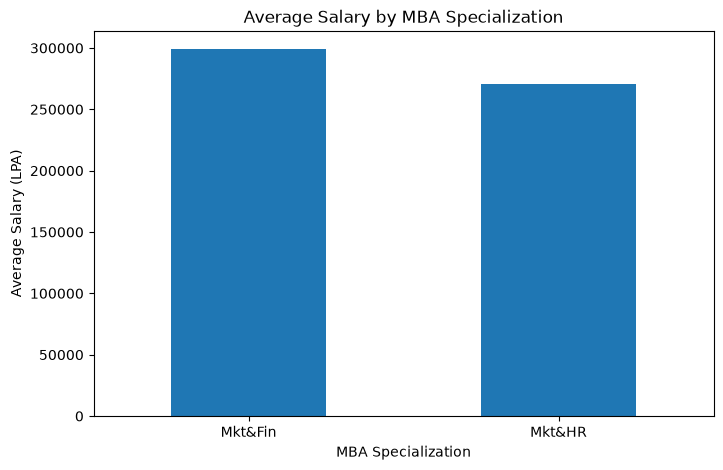

In [11]:
# ============================================================
# SALARY ANALYSIS — MBA SPECIALIZATION
# ============================================================

salary_by_specialisation = (
    placed_students
    .groupby("specialisation")["salary"]
    .mean()
    .sort_values(ascending=False)
)

print("Average salary by MBA specialization:")
display(salary_by_specialisation)

plt.figure(figsize=(8, 5))

salary_by_specialisation.plot(kind="bar")

plt.title("Average Salary by MBA Specialization")
plt.xlabel("MBA Specialization")
plt.ylabel("Average Salary (LPA)")
plt.xticks(rotation=0)

plt.show()

Correlation Matrix:


,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
ssc_p,1.000000,0.511472,0.538404,0.261993,0.388478,0.035330
hsc_p,0.511472,1.000000,0.434206,0.245113,0.354823,0.076819
degree_p,0.538404,0.434206,1.000000,0.224470,0.402364,-0.019272
etest_p,0.261993,0.245113,0.224470,1.000000,0.218055,0.178307
mba_p,0.388478,0.354823,0.402364,0.218055,1.000000,0.175013
salary,0.035330,0.076819,-0.019272,0.178307,0.175013,1.000000


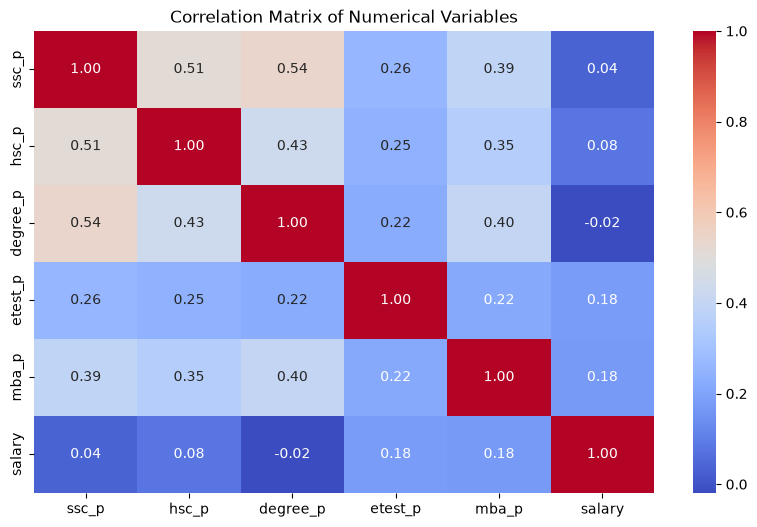

In [12]:
# ============================================================
# DIAGNOSTIC ANALYSIS — CORRELATION MATRIX
# ============================================================

numeric_columns = [
    "ssc_p",
    "hsc_p",
    "degree_p",
    "etest_p",
    "mba_p",
    "salary"
]

correlation_matrix = df[numeric_columns].corr()

print("Correlation Matrix:")
display(correlation_matrix)

plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Variables")

plt.show()

In [17]:
# ============================================================
# BUSINESS INSIGHT SUMMARY
# ============================================================

# Work experience placement rate
workex_rates = (
    df.groupby("workex")["status"]
    .apply(lambda x: (x == "Placed").mean() * 100)
)

# Degree group placement rate
degree_rates = (
    df.groupby("degree_group", observed=True)["status"]
    .apply(lambda x: (x == "Placed").mean() * 100)
)

# Entrance test placement rate
etest_rates = (
    df.groupby("etest_group", observed=True)["status"]
    .apply(lambda x: (x == "Placed").mean() * 100)
)

# Specialization placement rate
specialisation_rates = (
    df.groupby("specialisation")["status"]
    .apply(lambda x: (x == "Placed").mean() * 100)
)

print("WORK EXPERIENCE")
display(workex_rates.round(2))

print("\nDEGREE PERFORMANCE")
display(degree_rates.round(2))

print("\nENTRANCE TEST PERFORMANCE")
display(etest_rates.round(2))

print("\nMBA SPECIALIZATION")
display(specialisation_rates.round(2))

WORK EXPERIENCE


workex
No     59.57
Yes    86.49
Name: status, dtype: float64


DEGREE PERFORMANCE


degree_group
Below 60     31.25
60-70        73.33
70-80        89.09
80+         100.00
Name: status, dtype: float64


ENTRANCE TEST PERFORMANCE


etest_group
Below 50    33.33
50-60       66.07
60-70       64.58
70-80       63.83
80+         80.33
Name: status, dtype: float64


MBA SPECIALIZATION


specialisation
Mkt&Fin    79.17
Mkt&HR     55.79
Name: status, dtype: float64

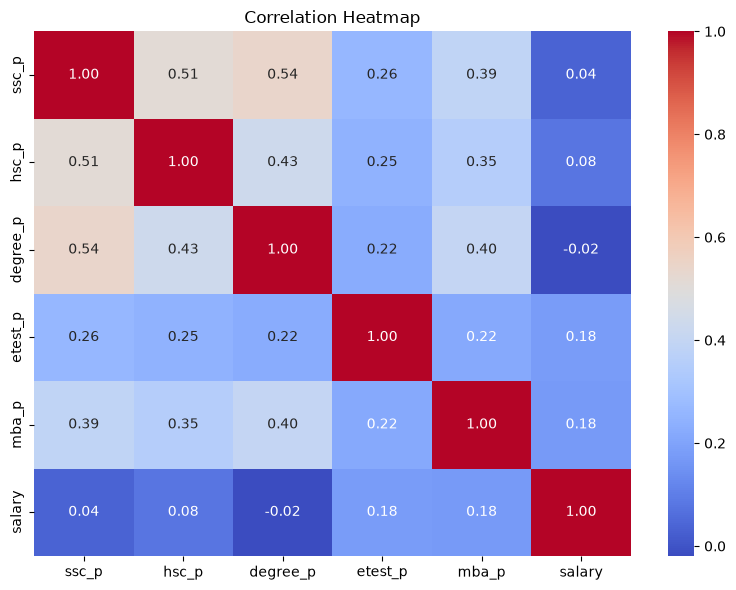

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("data/Placement_Data_Full_Class.csv")

# Remove unnecessary serial number column
df = df.drop(columns=["sl_no"])

# Select numerical columns
numeric_columns = [
    "ssc_p",
    "hsc_p",
    "degree_p",
    "etest_p",
    "mba_p",
    "salary"
]

# Calculate correlation matrix
correlation_matrix = df[numeric_columns].corr()

# Create correlation heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

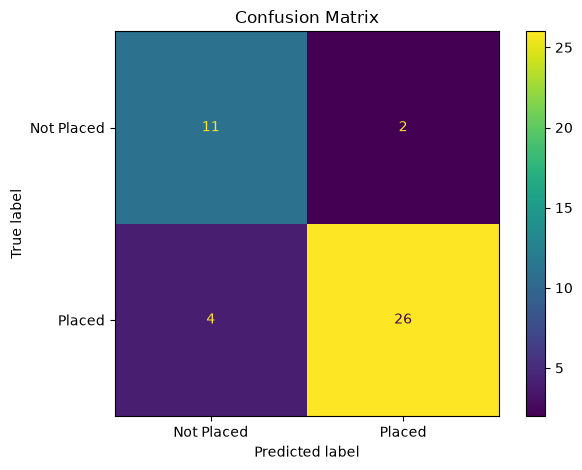

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load dataset
df = pd.read_csv("data/Placement_Data_Full_Class.csv")

# Remove serial number
df = df.drop(columns=["sl_no"])

# Create target
df["placement_target"] = (df["status"] == "Placed").astype(int)

# Features and target
X = df.drop(columns=["status", "salary", "placement_target"])
y = df["placement_target"]

# Identify columns
numeric_features = [
    "ssc_p",
    "hsc_p",
    "degree_p",
    "etest_p",
    "mba_p"
]

categorical_features = [
    "gender",
    "ssc_b",
    "hsc_b",
    "hsc_s",
    "degree_t",
    "workex",
    "specialisation"
]

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Model
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Train model
model.fit(X_train, y_train)

# Generate predictions
y_pred = model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Placed", "Placed"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

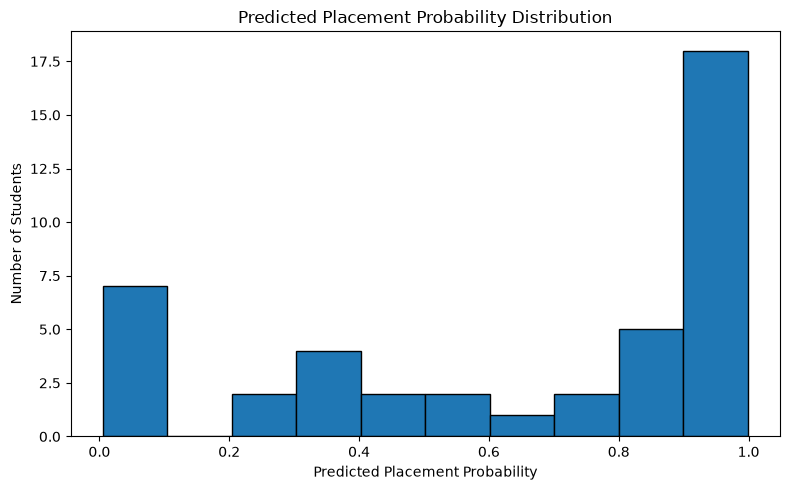

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Load dataset
df = pd.read_csv("data/Placement_Data_Full_Class.csv")

# Remove serial number
df = df.drop(columns=["sl_no"])

# Create target
df["placement_target"] = (df["status"] == "Placed").astype(int)

# Features and target
X = df.drop(columns=["status", "salary", "placement_target"])
y = df["placement_target"]

numeric_features = [
    "ssc_p", "hsc_p", "degree_p", "etest_p", "mba_p"
]

categorical_features = [
    "gender", "ssc_b", "hsc_b", "hsc_s",
    "degree_t", "workex", "specialisation"
]

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Logistic Regression model
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Train model
model.fit(X_train, y_train)

# Get placement probabilities
placement_probabilities = model.predict_proba(X_test)[:, 1]

# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(
    placement_probabilities,
    bins=10,
    edgecolor="black"
)

plt.xlabel("Predicted Placement Probability")
plt.ylabel("Number of Students")
plt.title("Predicted Placement Probability Distribution")
plt.tight_layout()
plt.show()